# Single-Window Forecast: Multi-Checkpoint Comparison

This notebook extracts the single-window forecast comparison from `forecasting_induced_eq_triplet.ipynb` and puts multiple checkpoints into one figure.

Recommended layout:
- Use one row per checkpoint for 4 or 6 checkpoints; this preserves the full time axis and makes trajectories easier to compare.
- Remove the right-side forecast-count histogram subplot; keep only a compact row annotation with mean/median/95% count interval.
- Keep a thin right y-axis for cumulative count because the forecast trajectories are counting-process paths, not magnitude points.
- Use `N_COLS = 2` only for slides or compact drafts; for paper figures, `N_COLS = 1` is usually cleaner.

## 1) Setup

In [34]:
import gc
import inspect
import sys
from collections import OrderedDict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, VPacker
from matplotlib.patches import Patch


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError('Cannot find project root containing src directory.')


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.models.updaters import UpdaterSamplingWrapper, build_sampling_updater
from src.train.config_setup import load_and_prepare_model
from src.utils.forecast_eval import apply_publication_style, save_pub_figure
from src.utils.runtime_utils import unwrap_compiled_model
from src.utils.tpp_experiments import load_tpp_catalog, sample_tpp_forecasts
from src.utils.utils import set_seed
from src.utils.viz_sequences import plot_counting_process, visualize_sequence

apply_publication_style()
SANS_SERIF_FONTS = [
    'Arial', 'Helvetica', 'Liberation Sans', 'Nimbus Sans', 'DejaVu Sans',
]
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': SANS_SERIF_FONTS,
    'mathtext.fontset': 'dejavusans',
})
set_seed(0)

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR = PROJECT_ROOT / 'notebooks' / 'figs' / 'forecast_nxm'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DEVICE: {DEVICE}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')

PROJECT_ROOT: /root/autodl-tmp/em_eqf
DEVICE: cuda:0
OUTPUT_DIR: /root/autodl-tmp/em_eqf/notebooks/figs/forecast_nxm


## 2) Checkpoints

In [35]:
import os
import json

NOTEBOOK_NAME = 'forecast_nxm'
DEFAULT_MODEL_SPEC_CONFIG_NAME = 'St1_2018'
MODEL_SPEC_CONFIG_NAME = os.environ.get('MODEL_SPEC_CONFIG_NAME', DEFAULT_MODEL_SPEC_CONFIG_NAME)


def forecast_export_stem(spec_config_name: str, ncols: int) -> str:
    """Return a concise, configuration-specific figure name."""
    if not spec_config_name:
        raise ValueError('spec_config_name must be non-empty.')
    if int(ncols) < 1:
        raise ValueError('ncols must be positive.')
    return f'forecast_{spec_config_name}_{int(ncols)}col'

MODEL_SPEC_CONFIG_ROOT = PROJECT_ROOT / 'notebooks' / 'config' / 'model_specs'
MODEL_SPEC_CONFIG_DIR = MODEL_SPEC_CONFIG_ROOT / NOTEBOOK_NAME
MODEL_SPEC_CONFIG_PATH = MODEL_SPEC_CONFIG_DIR / f'model_specs.{NOTEBOOK_NAME}.v1.json'


def resolve_ckpt_path(path_like) -> Path:
    path = Path(path_like).expanduser()
    return path if path.is_absolute() else PROJECT_ROOT / path


def load_model_spec_catalog(config_path: Path) -> dict:
    if not config_path.exists():
        raise FileNotFoundError(f'Model spec config file not found: {config_path}')
    with open(config_path, 'r', encoding='utf-8') as f:
        catalog = json.load(f)
    config_map = catalog.get('configs', {})
    if not isinstance(config_map, dict) or not config_map:
        raise ValueError(f'Invalid config format in {config_path}: missing non-empty "configs".')
    return catalog


def print_available_configs(config_map: dict) -> None:
    print('Available model spec configs:')
    for cfg_name in sorted(config_map):
        cfg = config_map[cfg_name]
        cfg_desc = cfg.get('description') or ''
        cfg_models = cfg.get('models', [])
        cfg_model_count = len(cfg_models) if isinstance(cfg_models, list) else 0
        if cfg_desc:
            print(f'  - {cfg_name}: {cfg_desc} (models={cfg_model_count})')
        else:
            print(f'  - {cfg_name} (models={cfg_model_count})')


def build_checkpoint_specs(config_name: str, config_map: dict) -> tuple[dict, list[dict]]:
    if config_name not in config_map:
        available = ', '.join(sorted(config_map))
        raise KeyError(f'Unknown MODEL_SPEC_CONFIG_NAME={config_name}. Available: {available}')

    cfg = config_map[config_name]
    raw_specs = cfg.get('models', [])
    if not isinstance(raw_specs, list) or not raw_specs:
        raise ValueError(f'Config "{config_name}" has no models in {MODEL_SPEC_CONFIG_PATH}.')

    specs = []
    for index, item in enumerate(raw_specs):
        if 'label' not in item:
            raise KeyError(f'Model item {index} in config "{config_name}" must contain "label".')
        if 'checkpoint_rel_path' in item:
            path = item['checkpoint_rel_path']
        elif 'path' in item:
            path = item['path']
        else:
            raise KeyError(
                f'Model item {index} in config "{config_name}" must contain '
                '"checkpoint_rel_path" or "path".'
            )
        specs.append({'label': item['label'], 'path': path})
    return cfg, specs


def print_selected_config_summary(config_name: str, cfg: dict, specs: list[dict]) -> None:
    print(f'Loaded MODEL_SPECS config: {config_name}')
    if cfg.get('description'):
        print(f"Config description: {cfg['description']}")
    print(f'Number of models: {len(specs)}')
    for spec in specs:
        ckpt_path = resolve_ckpt_path(spec['path'])
        status = 'OK' if ckpt_path.exists() else 'MISSING'
        print(f'{status}: {spec["label"]}: {ckpt_path}')


model_spec_catalog = load_model_spec_catalog(MODEL_SPEC_CONFIG_PATH)
config_map = model_spec_catalog['configs']
print_available_configs(config_map)

selected_model_spec_cfg, MODEL_SPECS = build_checkpoint_specs(MODEL_SPEC_CONFIG_NAME, config_map)
CKPT_SPECS = MODEL_SPECS
print_selected_config_summary(MODEL_SPEC_CONFIG_NAME, selected_model_spec_cfg, CKPT_SPECS)

Available model spec configs:
  - CB_HAB1a: CB_HAB1a forecast comparison: ETAS and RECAST background models (models=6)
  - CB_HAB4: CB_HAB4 forecast comparison: ETAS and RECAST background models (models=6)
  - PNR_1z: Current forecast_nxm comparison: ETAS and RECAST background models (models=6)
  - PNR_1z_full: PNR_1z forecast comparison: ETAS family + RECAST family + Oracle (models=9)
  - St1_2018: St1-2018 forecast comparison: ETAS and RECAST background models (models=6)
Loaded MODEL_SPECS config: St1_2018
Config description: St1-2018 forecast comparison: ETAS and RECAST background models
Number of models: 6
OK: ETAS + p: /root/autodl-tmp/em_eqf/experiments/etas_multi_ds_bg_split_0.7/runs/etas__St1_2018_proportional_seed_1/best_model_1.pth
OK: ETAS + conv: /root/autodl-tmp/em_eqf/experiments/etas_multi_ds_bg_split_0.7/runs/etas__St1_2018_kernel_seed_1/best_model_1.pth
OK: ETAS + Mamba: /root/autodl-tmp/em_eqf/experiments/etas_multi_ds_bg_split_0.7/runs/etas__St1_2018_mamba_seed_1/bes

## 3) Single-Window Settings

In [36]:
T_FORECAST = 35
FORECAST_DURATION = 10
NUM_SAMPLES = 1000
SAMPLES_PER_BATCH = min(NUM_SAMPLES, 1000)
SAMPLE_SEED = 3
USE_SHARED_SAMPLE_SEED = True

NUM_EXAMPLES = 18
EXAMPLE_OFFSET = 0
T_BEFORE = 0

USE_TORCH_COMPILE = False
MODEL_MM = 4

FORECAST_B_SAMPLING = 'model'
UPDATER_NAME = 'bayesian_gr'
UPDATER_CFG = {
    'delta': 0.98,
    'a0': 50,
    'init_b_target': 1,
}

window_start = float(T_FORECAST)
window_end = float(T_FORECAST + FORECAST_DURATION)
print(f'Forecast window: [{window_start:g}, {window_end:g}]')
print(f'Forecast samples per checkpoint: {NUM_SAMPLES}')

Forecast window: [35, 45]
Forecast samples per checkpoint: 1000


## 4) Load Catalog and Window

In [37]:
bootstrap_path = resolve_ckpt_path(CKPT_SPECS[0]['path'])
bootstrap_model, bootstrap_args = load_and_prepare_model(
    checkpoint_path=bootstrap_path,
    device=DEVICE,
    compile=USE_TORCH_COMPILE,
)
bootstrap_model = unwrap_compiled_model(bootstrap_model)

catalog_cfg = getattr(bootstrap_args, 'catalog_cfg', {})
catalog_ds, registry_name, catalog_init_kwargs = load_tpp_catalog(
    bootstrap_args.dataset,
    base_dir=PROJECT_ROOT / 'data' / bootstrap_args.dataset,
    catalog_cfg=catalog_cfg,
)

del bootstrap_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

full_seq = catalog_ds.full_sequence
sequences = catalog_ds.sequences if hasattr(catalog_ds, 'sequences') else [full_seq]
SEQUENCE_IDX = 0
seq = sequences[SEQUENCE_IDX]
mc = catalog_ds.metadata['mag_completeness']

past_seq = seq.get_subsequence(0, T_FORECAST, reset_t_nll_to_end=True)
observed_seq = seq.get_subsequence(T_FORECAST, T_FORECAST + FORECAST_DURATION, reset_t_nll_to_end=True)

metadata_start = catalog_ds.metadata.get('start_ts', 'start')
date_label = metadata_start.strftime('%Y-%m-%d') if hasattr(metadata_start, 'strftime') else str(metadata_start)

print(f'Catalog registry name: {registry_name}')
print(f'Dataset: {bootstrap_args.dataset}')
print(f'Sequence index: {SEQUENCE_IDX}')
print(f'Observed events in window: {len(observed_seq)}')
print(f'Magnitude completeness: {mc}')

/root/autodl-tmp/em_eqf/src/data/sequence.py:370: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


Catalog registry name: St1-2018-Standard
Dataset: St1-2018
Sequence index: 0
Observed events in window: 5699
Magnitude completeness: -0.5


## 5) Forecast Sampling Helpers

In [38]:
def supports_dynamic_b_sampling(model) -> bool:
    try:
        parameters = inspect.signature(model.sample).parameters
        if any(name in parameters for name in ('b_sampling', 'updater', 'updater_name', 'updater_cfg')):
            return True
    except Exception:
        pass
    return hasattr(model, '_normalize_b_sampling_mode')


def prepare_model_for_sampling(model, args):
    if MODEL_MM is not None and hasattr(model, 'M_m'):
        model.M_m = torch.tensor(float(MODEL_MM), device=DEVICE)
    predict_b = bool(getattr(args, 'predict_b', False))
    if hasattr(model, 'predict_b'):
        model.predict_b = predict_b
    return predict_b


def make_sampling_model(model, mc_value):
    if FORECAST_B_SAMPLING != 'updater':
        return model, 'model'
    if not supports_dynamic_b_sampling(model):
        print(f'{type(model).__name__} does not support updater b sampling; using model b.')
        return model, 'model'

    def updater_factory():
        return build_sampling_updater(
            model=model,
            mc=float(mc_value),
            updater_name=UPDATER_NAME,
            updater_cfg=dict(UPDATER_CFG or {}),
            device=getattr(model, 'device', DEVICE),
        )

    wrapped_model = UpdaterSamplingWrapper(
        model,
        sampling_mode=FORECAST_B_SAMPLING,
        updater_factory=updater_factory,
    )
    return wrapped_model, FORECAST_B_SAMPLING


def move_forecasts_to_cpu(forecasts):
    return [forecast.cpu() if hasattr(forecast, 'cpu') else forecast for forecast in forecasts]


def summarize_forecasts(label, ckpt_path, args, forecasts, predict_b, b_sampling):
    counts = np.asarray([len(forecast) for forecast in forecasts], dtype=float)
    q025, q50, q975 = np.quantile(counts, [0.025, 0.5, 0.975]) if counts.size else (np.nan, np.nan, np.nan)
    zero_inter_time_count = 0
    for forecast in forecasts:
        inter_times = torch.as_tensor(forecast.inter_times).detach().cpu()
        zero_inter_time_count += int((inter_times == 0).any().item())
    return {
        'label': label,
        'model': str(getattr(args, 'model', '')),
        'dataset': str(getattr(args, 'dataset', '')),
        'predict_b': predict_b,
        'b_sampling': b_sampling,
        'num_samples': len(forecasts),
        'obs_count': len(observed_seq),
        'mean_count': float(np.mean(counts)) if counts.size else np.nan,
        'median_count': float(q50),
        'q025_count': float(q025),
        'q975_count': float(q975),
        'count_abs_error_mean': float(abs(np.mean(counts) - len(observed_seq))) if counts.size else np.nan,
        'zero_inter_time_forecasts': zero_inter_time_count,
        'checkpoint': str(ckpt_path),
    }


def sample_forecasts_for_checkpoint(spec, index):
    label = spec['label']
    ckpt_path = resolve_ckpt_path(spec['path'])
    if not ckpt_path.exists():
        raise FileNotFoundError(f'Checkpoint not found: {ckpt_path}')

    print(f'[{index + 1}/{len(CKPT_SPECS)}] Loading {label}')
    model, args = load_and_prepare_model(
        checkpoint_path=ckpt_path,
        device=DEVICE,
        compile=USE_TORCH_COMPILE,
    )
    model = unwrap_compiled_model(model)

    if str(getattr(args, 'dataset', '')) != str(bootstrap_args.dataset):
        print(f'Warning: {label} dataset={getattr(args, "dataset", None)} differs from bootstrap dataset={bootstrap_args.dataset}')

    predict_b = prepare_model_for_sampling(model, args)
    sampling_model, b_sampling = make_sampling_model(model, mc)
    past_seq_device = past_seq.to(DEVICE) if torch.cuda.is_available() else past_seq

    forecasts = sample_tpp_forecasts(
        model=sampling_model,
        past_seq=past_seq_device,
        duration=FORECAST_DURATION,
        num_samples=NUM_SAMPLES,
        samples_per_batch=SAMPLES_PER_BATCH,
        bg_cache_seq=seq,
        seed=SAMPLE_SEED if USE_SHARED_SAMPLE_SEED else SAMPLE_SEED + index,
        predict_b=predict_b,
    )
    forecasts = move_forecasts_to_cpu(forecasts)
    summary = summarize_forecasts(label, ckpt_path, args, forecasts, predict_b, b_sampling)

    del sampling_model
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(f'  sampled={len(forecasts)}, mean_count={summary["mean_count"]:.2f}, 95%=[{summary["q025_count"]:.0f}, {summary["q975_count"]:.0f}]')
    return forecasts, summary

## 6) Run Forecasts

In [39]:
forecasts_by_label = OrderedDict()
summary_rows = []

for ckpt_index, ckpt_spec in enumerate(CKPT_SPECS):
    ckpt_forecasts, ckpt_summary = sample_forecasts_for_checkpoint(ckpt_spec, ckpt_index)
    forecasts_by_label[ckpt_spec['label']] = ckpt_forecasts
    summary_rows.append(ckpt_summary)

summary_df = pd.DataFrame(summary_rows)
summary_df

[1/6] Loading ETAS + p


  0%|          | 0/1000 [00:00<?, ?it/s]

/root/autodl-tmp/em_eqf/src/data/sequence.py:370: UserWarning: Found 3 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


  sampled=1000, mean_count=5645.88, 95%=[4785, 6653]
[2/6] Loading ETAS + conv


  0%|          | 0/1000 [00:00<?, ?it/s]

...

  sampled=1000, mean_count=5397.19, 95%=[4225, 6737]
[3/6] Loading ETAS + Mamba


  0%|          | 0/1000 [00:00<?, ?it/s]

/root/autodl-tmp/em_eqf/src/data/sequence.py:370: UserWarning: Found 5 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/em_eqf/src/data/sequence.py:370: UserWarning: Found 5 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/em_eqf/src/data/sequence.py:370: UserWarning: Found 4 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/em_eqf/src/data/sequence.py:370: UserWarning: Found 4 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/em_eqf/src/data/sequence.py:370: UserWarning: Found 4 zero inter-ev

  sampled=1000, mean_count=5548.33, 95%=[4996, 6294]
[4/6] Loading RECAST + p
  sampled=1000, mean_count=5043.32, 95%=[1456, 6425]
[5/6] Loading RECAST + conv
  sampled=1000, mean_count=3060.44, 95%=[480, 5036]
[6/6] Loading RECAST + Mamba
  sampled=1000, mean_count=4872.40, 95%=[1167, 5737]


,label,model,dataset,predict_b,b_sampling,num_samples,obs_count,mean_count,median_count,q025_count,q975_count,count_abs_error_mean,zero_inter_time_forecasts,checkpoint
0,ETAS + p,etas,St1-2018,False,model,1000,5699,5645.882,5617.5,4784.900,6653.025,53.118,248,/root/autodl-tmp/em_eqf/experiments/etas_multi...
1,ETAS + conv,etas,St1-2018,False,model,1000,5699,5397.189,5366.0,4224.825,6737.400,301.811,479,/root/autodl-tmp/em_eqf/experiments/etas_multi...
2,ETAS + Mamba,etas,St1-2018,False,model,1000,5699,5548.332,5516.0,4995.750,6294.100,150.668,668,/root/autodl-tmp/em_eqf/experiments/etas_multi...
3,RECAST + p,rtpp_v2,St1-2018,False,model,1000,5699,5043.317,5205.5,1456.225,6425.100,655.683,0,/root/autodl-tmp/em_eqf/experiments/rtpp_v2_mu...
4,RECAST + conv,rtpp_v2,St1-2018,False,model,1000,5699,3060.443,3645.0,479.950,5036.050,2638.557,0,/root/autodl-tmp/em_eqf/experiments/rtpp_v2_mu...
5,RECAST + Mamba,rtpp_v2,St1-2018,False,model,1000,5699,4872.401,5202.0,1167.125,5737.025,826.599,0,/root/autodl-tmp/em_eqf/experiments/rtpp_v2_mu...


## 7) Plot Without the Right Histogram Subplot

In [40]:
def selected_forecasts(forecasts, num_examples, offset):
    if not forecasts:
        return []
    safe_offset = max(0, min(int(offset), len(forecasts) - 1))
    safe_num_examples = min(int(num_examples), len(forecasts) - safe_offset)
    return forecasts[safe_offset:safe_offset + safe_num_examples]


def count_stats_text(forecasts, observed_count):
    counts = np.asarray([len(forecast) for forecast in forecasts], dtype=float)
    if counts.size == 0:
        return f'obs={observed_count}\nno forecasts'
    q025, q50, q975 = np.quantile(counts, [0.025, 0.5, 0.975])
    return f'mean={counts.mean():.1f}, med={q50:.0f}\n95%=[{q025:.0f}, {q975:.0f}], obs={observed_count}'


def publication_model_label(label):
    # Normalize legacy lower-case display labels without touching checkpoint paths.
    return str(label).replace('mamba', 'Mamba')


def add_panel_annotation(ax, panel_label, stats_text):
    # Anchor the panel label and summary inside the data axes.
    title = TextArea(panel_label, textprops=dict(fontsize=9, fontweight='bold'))
    stats = TextArea(stats_text, textprops=dict(fontsize=8, linespacing=1.15))
    content = VPacker(children=[title, stats], align='left', pad=0, sep=3)
    annotation = AnchoredOffsetbox(
        loc='upper left',
        child=content,
        frameon=True,
        pad=0.18,
        borderpad=0,
        bbox_to_anchor=(0.012, 0.985),
        bbox_transform=ax.transAxes,
    )
    annotation.patch.set_facecolor('white')
    annotation.patch.set_edgecolor('none')
    annotation.patch.set_alpha(0.82)
    annotation.set_zorder(10)
    ax.add_artist(annotation)
    return annotation


def common_count_limit(forecasts_by_model, observed_count, num_examples, offset):
    candidates = [float(observed_count), 1.0]
    for forecasts in forecasts_by_model.values():
        counts = np.asarray([len(forecast) for forecast in forecasts], dtype=float)
        if counts.size:
            candidates.append(float(np.quantile(counts, 0.975)))
        candidates.extend(float(len(forecast)) for forecast in selected_forecasts(forecasts, num_examples, offset))
    return max(candidates) * 1.08


def plot_single_window_ckpt_comparison(
    seq,
    forecasts_by_model,
    observed_seq,
    *,
    t_start,
    t_end,
    t_before,
    num_examples,
    offset=0,
    ncols=1,
    figsize=None,
    xlabel='Days since start',
):
    labels = list(forecasts_by_model.keys())
    if not labels:
        raise ValueError('forecasts_by_model must be non-empty')

    ncols = max(1, int(ncols))
    nrows = int(np.ceil(len(labels) / ncols))
    if figsize is None:
        plot_row_height = 1.9 if ncols == 1 else 2.25
        width = 9.4 if ncols == 1 else 10.8
        figsize = (width, max(3.8, plot_row_height * nrows + 0.7))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharex=True,
        squeeze=False,
        constrained_layout=True,
    )

    plot_colors = plt.rcParams['axes.prop_cycle'].by_key().get('color', [])
    default_forecast_color = plot_colors[1] if len(plot_colors) > 1 else '#F28E2B'
    s_viz = seq.get_subsequence(t_start - t_before, t_end, reset_t_nll_to_end=True).cpu()
    s_obs = observed_seq.cpu() if hasattr(observed_seq, 'cpu') else observed_seq
    observed_count = len(s_obs)
    count_ymax = common_count_limit(forecasts_by_model, observed_count, num_examples, offset)
    count_axes = []

    for panel_index, label in enumerate(labels):
        row = panel_index // ncols
        col = panel_index % ncols
        ax = axes[row, col]
        forecast_color = default_forecast_color
        forecasts = forecasts_by_model[label]

        if t_before > 0:
            ax.axvspan(t_start, t_end, color='#C2D9F8', alpha=0.22, lw=0)
        ax.axvline(t_start, color='black', lw=0.9, ls='--', alpha=0.75)
        visualize_sequence(
            s_viz,
            ax=ax,
            event_color='0.25',
            mag_completeness=mc,
            t_start=t_start - t_before,
            t_end=t_end,
            show_legend=False,
            xlabel=xlabel,
        )
        ax.set_xlim(t_start - t_before, t_end)
        ax.grid(axis='x', alpha=0.25, linestyle='--', linewidth=0.6)
        ax.tick_params(axis='both', labelsize=8)
        ax.set_ylabel('Magnitude', fontsize=9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        ax_count = ax.twinx()
        plot_counting_process(
            s_obs,
            ax_count,
            color='black',
            alpha=0.95,
            T0=t_start,
            T=t_end,
            linewidth=1.8,
            zorder=5,
        )
        for forecast in selected_forecasts(forecasts, num_examples, offset):
            forecast_cpu = forecast.cpu() if hasattr(forecast, 'cpu') else forecast
            plot_counting_process(
                forecast_cpu,
                ax_count,
                color=forecast_color,
                alpha=0.42,
                T0=t_start,
                T=t_end,
                linewidth=1.1,
                zorder=2,
            )
        ax_count.set_ylim(0, count_ymax)
        ax_count.tick_params(axis='y', labelsize=8)
        ax_count.grid(False)
        count_axes.append(ax_count)

        display_label = publication_model_label(label)
        panel_label = f'({chr(ord("a") + panel_index)}) {display_label}'
        add_panel_annotation(ax_count, panel_label, count_stats_text(forecasts, observed_count))

        if col == ncols - 1:
            ax_count.set_ylabel('Cumulative count', fontsize=9)
        else:
            ax_count.set_ylabel('')
            ax_count.tick_params(axis='y', labelright=False)
        if row < nrows - 1:
            ax.set_xlabel('')
            ax.tick_params(axis='x', labelbottom=False)

    for empty_index in range(len(labels), nrows * ncols):
        row = empty_index // ncols
        col = empty_index % ncols
        axes[row, col].set_axis_off()

    legend_handles = []
    if t_before > 0:
        legend_handles.append(Patch(facecolor='#C2D9F8', edgecolor='none', alpha=0.22, label='Forecast window'))
    legend_handles.extend([
        Line2D([0], [0], color='black', lw=1.8, label='Observed count'),
        Line2D([0], [0], color=default_forecast_color, lw=1.2, alpha=0.6, label='Sample forecast counts'),
    ])
    fig.legend(
        handles=legend_handles,
        loc='lower center',
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 1.012),
    )
    return fig, axes, count_axes

## 8) Recommended Figure

Exports use `forecast_{MODEL_SPEC_CONFIG_NAME}_{N_COLS}col`, so files from different spec configurations and layouts do not overwrite one another.

Saved: /root/autodl-tmp/em_eqf/notebooks/figs/forecast_nxm/forecast_St1_2018_3col.pdf
Saved: /root/autodl-tmp/em_eqf/notebooks/figs/forecast_nxm/forecast_St1_2018_3col.png


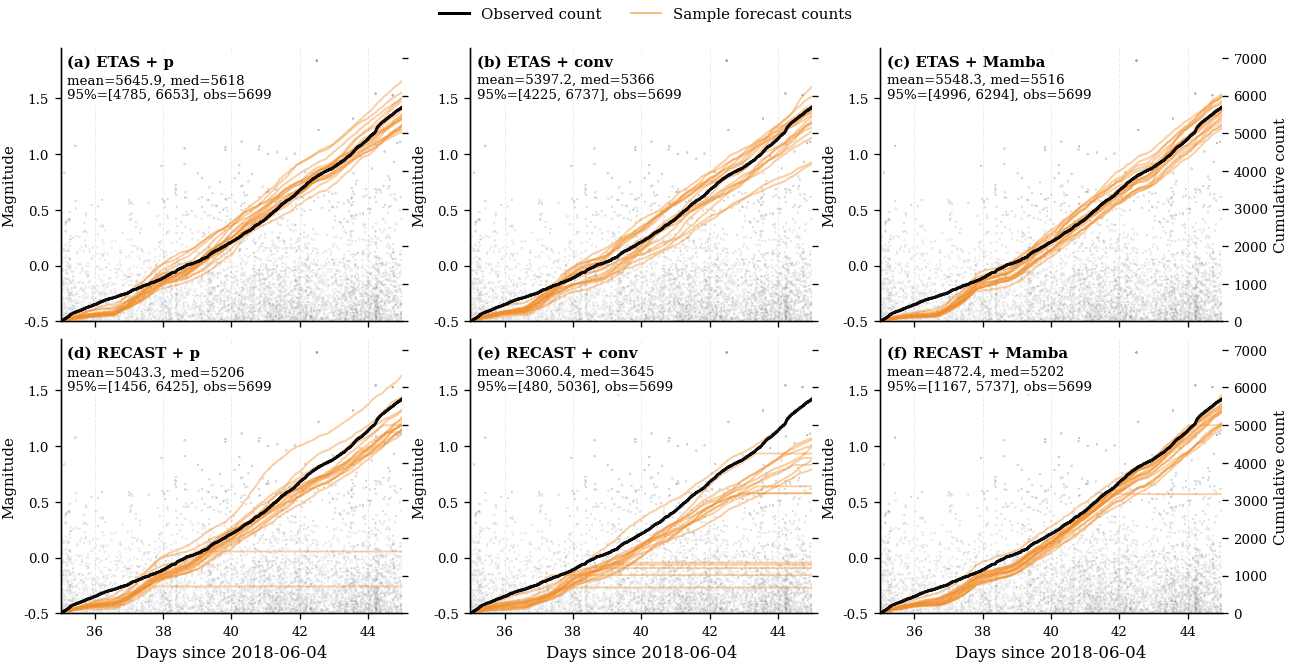

In [41]:
N_COLS = 3

fig, axes, count_axes = plot_single_window_ckpt_comparison(
    seq,
    forecasts_by_label,
    observed_seq,
    t_start=window_start,
    t_end=window_end,
    t_before=T_BEFORE,
    num_examples=NUM_EXAMPLES,
    offset=EXAMPLE_OFFSET,
    ncols=N_COLS,
    xlabel='Days since ' + date_label,
)

figure_stem = forecast_export_stem(MODEL_SPEC_CONFIG_NAME, N_COLS)
pdf_path = save_pub_figure(fig, OUTPUT_DIR / figure_stem, file_format='pdf')
png_path = save_pub_figure(fig, OUTPUT_DIR / figure_stem, file_format='png')
print(f'Saved: {pdf_path}')
print(f'Saved: {png_path}')
plt.show()

## 9) Optional Compact Layout

The compact export follows the same rule and uses its actual column count.

In [42]:
MAKE_COMPACT_LAYOUT = False

if MAKE_COMPACT_LAYOUT:
    compact_ncols = 2
    compact_fig, compact_axes, compact_count_axes = plot_single_window_ckpt_comparison(
        seq,
        forecasts_by_label,
        observed_seq,
        t_start=window_start,
        t_end=window_end,
        t_before=T_BEFORE,
        num_examples=NUM_EXAMPLES,
        offset=EXAMPLE_OFFSET,
        ncols=compact_ncols,
        xlabel='Days since ' + date_label,
    )
    compact_stem = forecast_export_stem(MODEL_SPEC_CONFIG_NAME, compact_ncols)
    compact_pdf_path = save_pub_figure(compact_fig, OUTPUT_DIR / compact_stem, file_format='pdf')
    compact_png_path = save_pub_figure(compact_fig, OUTPUT_DIR / compact_stem, file_format='png')
    print(f'Saved: {compact_pdf_path}')
    print(f'Saved: {compact_png_path}')
    plt.show()